In [11]:
import glob
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


ts_re = re.compile(r"^\d{2}:\d{2}:\d{2}", re.MULTILINE)
throughput_re = re.compile(r"""
Total\ Ops\s*:\s*(?P<total_ops>[\d.]+)\s+million\s*
Total\ sets\s*:\s*(?P<total_sets>[\d,]+)\s*
get\s*:\s*(?P<get_tput>[\d,]+)/s,\s*success\s*:\s*(?P<get_success>[\d.]+)%\s*
couldExist\s*:\s*(?P<couldexist_tput>[\d,]+)/s,\s*success\s*:\s*(?P<couldexist_success>[\d.]+)%\s*
set\s*:\s*(?P<set_tput>[\d,]+)/s,\s*success\s*:\s*(?P<set_success>[\d.]+)%\s*
del\s*:\s*(?P<del_tput>[\d,]+)/s,\s*found\s*:\s*(?P<del_found>[\d.]+)%
""", re.VERBOSE)
allocator_re = re.compile(r"""
Cache\ Gets\s*:\s*(?P<cache_gets>[\d,]+)\s*
Hit\ Ratio\s*:\s*(?P<alloc_hit_ratio>[\d.]+)%\s*
""", re.VERBOSE)
items_re = re.compile(r"""
Items\ in\ RAM\s*:\s*(?P<items_ram>[\d,]+)\s*
Items\ in\ NVM\s*:\s*(?P<items_nvm>[\d,]+)\s*
""", re.VERBOSE)
lat_re = re.compile(r"""
Cache\s+(?P<api>\w+)\s+API\s+latency\s+
p(?P<pct>\d+)\s*:\s*
(?P<value>[\d.]+)\s*ns
""", re.VERBOSE)

RESULT_GLOBS = [
    (
        "./results_benchmark/**/log*.txt", None
    ),
    # ("./results_new_s4fifo_splice/**/log*.txt", None),
    # # ("./results_new_s3fifo_pranav_batchmove/**/log*.txt", None),
]


def split_blocks(text):
    positions = [match.start() for match in ts_re.finditer(text)]
    blocks = []
    for index, start in enumerate(positions):
        end = positions[index + 1] if index + 1 < len(positions) else len(text)
        blocks.append(text[start:end].strip())
    return blocks


def safe_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return value


def parse_log_file(path):
    with open(path, "r", encoding="utf-8") as log_file:
        text = log_file.read()

    for block in split_blocks(text):
        row = {}

        allocator_match = allocator_re.search(block)
        if allocator_match:
            row.update(
                {
                    key: safe_float(value.replace(",", ""))
                    for key, value in allocator_match.groupdict().items()
                }
            )

        throughput_match = throughput_re.search(block)
        if throughput_match:
            row.update(
                {
                    key: safe_float(value.replace(",", ""))
                    for key, value in throughput_match.groupdict().items()
                }
            )

        items_match = items_re.search(block)
        if items_match:
            row.update(
                {
                    key: safe_float(value.replace(",", ""))
                    for key, value in items_match.groupdict().items()
                }
            )

        for latency_match in lat_re.finditer(block):
            api = latency_match.group("api")
            percentile = latency_match.group("pct")
            row[f"{api}_p{percentile}"] = safe_float(latency_match.group("value"))

        if row:
            return [row]

    return []


def get_algorithm(filename):
    name = filename.lower()
    suffix = ""
    suffix += "_navy" if "navy" in name else ""
    suffix += "_bhash" if "hash" in name else ""
    suffix += "_batch" if "batch" in name else ""
    suffix += "_minTailAge" if "minlrutail" in name else ""
    suffix += "_newest" if "withmainfilter" in name else ""

    if "log_s4fifo" in name:
        if "throughput" in name:
            return "s4fifo_throughput" + suffix
        if "s3" in name:
            return "s4fifo_s3" + suffix
        if "properg" in name:
            return "s4fifo_woutgremove" + suffix
        if "wgremove" in name:
            return "s4fifo_gremove" + suffix
        if "nocont" in name:
            return "s4fifo_non_continuous" + suffix
        return "s4fifo" + suffix

    if "log_s3" in name:
        if "s3fifo_v0" in name:
            return "s3fifo_v0" + suffix
        if "s3fifo_v1" in name:
            return "s3fifo_v1" + suffix
        if "s3fifo_v2" in name:
            return "s3fifo_v2" + suffix
        if "concurrent_nolock_deletes_v2" in name:
            return "s3fifo_conc_del64" + suffix
        if "nolock_nodel_v2" in name:
            return "s3fifo_con_32_nodel" + suffix
        if "delete" in name:
            return "s3fifo_conc_32_del" + suffix
        if "concurrent_nolock_v2" in name:
            return "s3fifo_concurrent_v2" + suffix
        if "ghost_nolock_v2" in name:
            return "s3fifo_gmutex_v2" + suffix
        if "concurrent" in name:
            return "s3fifo_last" + suffix
        if "mutex_unlock" in name:
            return "s3fifo_gmutex_unlock" + suffix
        if "proper" in name:
            return "s3fifo_gatomic_unlock" + suffix
        if "atomic" in name:
            return "s3fifo_gatomic" + suffix
        if "ghost_thread" in name:
            return "s3fifo_ghost_thread" + suffix
        if "ghost_mutex_onadd" in name:
            return "s3fifo_ghost_mutex_onadd" + suffix
        if "ghost_mutex" in name:
            return "s3fifo_gmutex" + suffix
        if "ghostout" in name:
            return "s3fifo_ghostout" + suffix
        if "noghost" in name:
            return "s3fifo_noghost" + suffix
        if "max_promote_skip" in name:
            return "s3fifo_limitpromote" + suffix
        if "noskip" in name:
            return "s3fifo_noskip" + suffix
        if "reserve" in name and "final" in name:
            return "s3fifo_opt_reserve" + suffix
        if "final" in name:
            return "s3fifo_opt_noreserve" + suffix
        return "s3fifo" + suffix

    if "2q" in name:
        return "lru2q" + suffix
    if "tiny" in name:
        return "tinylfu" + suffix
    return "lru" + suffix


def get_workload(path):
    name = path.lower()
    if "cdn" in name:
        return "cdn"
    if "leader_fbobj" in name:
        return "leader_fbobj"
    if "follower_fbobj" in name:
        return "follower_fbobj"
    if "leader_asso" in name:
        return "leader_assocs"
    if "follower_asso" in name:
        return "follower_assocs"
    return os.path.basename(os.path.dirname(path))


def collect_result_files():
    files = []
    for pattern, predicate in RESULT_GLOBS:
        matches = glob.glob(pattern, recursive=True)
        if predicate is not None:
            matches = [path for path in matches if predicate(path)]
        files.extend(matches)
    return sorted(set(files))


def load_all_results():
    rows = []
    files = collect_result_files()
    print(f"Found files: {len(files)}")

    for fullpath in files:
        parsed_rows = parse_log_file(fullpath)
        for row in parsed_rows:
            row["filename"] = os.path.basename(fullpath)
            row["algorithm"] = get_algorithm(fullpath)
            row["workload"] = get_workload(fullpath)
            rows.append(row)

    return pd.DataFrame(rows)


def build_color_map(df):
    algorithms = sorted(df["algorithm"].unique())
    palette = sns.color_palette("Set2", n_colors=len(algorithms))
    return {algorithm: palette[index] for index, algorithm in enumerate(algorithms)}


def plot_metric_per_workload(df, metric, title, ylabel, value_fmt="{:.2f}"):
    color_map = build_color_map(df)

    for workload in sorted(df["workload"].unique()):
        sub = df[df["workload"] == workload].copy()
        sub = sub[["algorithm", metric]].sort_values(metric)

        algorithms = sub["algorithm"].tolist()
        values = sub[metric].tolist()
        x = np.arange(len(algorithms))

        plt.figure(figsize=(9, 5))
        bars = plt.bar(
            x,
            values,
            width=0.55,
            color=[color_map[algorithm] for algorithm in algorithms],
            edgecolor="black",
            linewidth=1.0,
        )

        plt.title(f"{title} — Workload: {workload}", fontsize=14, weight="bold")
        plt.ylabel(ylabel, fontsize=12)
        plt.xticks(x, algorithms, rotation=25, fontsize=11)
        plt.grid(axis="y", linestyle="--", alpha=0.45)

        offset = max(values) * 0.01 if values else 0
        for rect, value in zip(bars, values):
            height = rect.get_height()
            plt.text(
                rect.get_x() + rect.get_width() / 2,
                height + offset,
                value_fmt.format(value),
                ha="center",
                va="bottom",
                fontsize=10,
                weight="semibold",
            )

        plt.tight_layout()
        plt.show()


def plot_throughput_per_workload_subplots(df, share_y=True):
    color_map = build_color_map(df)

    for workload in sorted(df["workload"].unique()):
        sub = df[df["workload"] == workload].copy().sort_values("algorithm")

        algorithms = sub["algorithm"].tolist()
        get_values = sub["get_tput"].tolist()
        set_values = sub["set_tput"].tolist()
        x = np.arange(len(algorithms))

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=share_y)
        ax_get, ax_set = axes

        bars_get = ax_get.bar(
            x,
            get_values,
            width=0.55,
            color=[color_map[algorithm] for algorithm in algorithms],
            edgecolor="black",
        )
        ax_get.set_title(f"GET Throughput — {workload}", fontsize=14, weight="bold")
        ax_get.set_ylabel("Ops/sec", fontsize=12)
        ax_get.set_xticks(x)
        ax_get.set_xticklabels(algorithms, rotation=25)
        ax_get.grid(axis="y", linestyle="--", alpha=0.45)

        get_offset = max(get_values) * 0.01 if get_values else 0
        for rect, value in zip(bars_get, get_values):
            ax_get.text(
                rect.get_x() + rect.get_width() / 2,
                value + get_offset,
                f"{value:,.0f}",
                ha="center",
                fontsize=10,
            )

        bars_set = ax_set.bar(
            x,
            set_values,
            width=0.55,
            color=[color_map[algorithm] for algorithm in algorithms],
            edgecolor="black",
        )
        ax_set.set_title(f"SET Throughput — {workload}", fontsize=14, weight="bold")
        ax_set.set_xticks(x)
        ax_set.set_xticklabels(algorithms, rotation=25)
        ax_set.grid(axis="y", linestyle="--", alpha=0.45)

        set_offset = max(set_values) * 0.01 if set_values else 0
        for rect, value in zip(bars_set, set_values):
            ax_set.text(
                rect.get_x() + rect.get_width() / 2,
                value + set_offset,
                f"{value:,.0f}",
                ha="center",
                fontsize=10,
            )

        plt.tight_layout()
        plt.show()


def plot_average_throughput(df):
    avg_df = (
        df.groupby("algorithm", as_index=False)
        .agg(get_tput=("get_tput", "mean"), set_tput=("set_tput", "mean"))
        .sort_values("algorithm")
    )

    algorithms = avg_df["algorithm"].tolist()
    get_values = avg_df["get_tput"].tolist()
    set_values = avg_df["set_tput"].tolist()
    color_map = build_color_map(avg_df)
    x = np.arange(len(algorithms))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    ax_get, ax_set = axes

    bars_get = ax_get.bar(
        x,
        get_values,
        width=0.55,
        color=[color_map[algorithm] for algorithm in algorithms],
        edgecolor="black",
    )
    ax_get.set_title("Average GET Throughput Across All Workloads", fontsize=14, weight="bold")
    ax_get.set_ylabel("Ops/sec", fontsize=12)
    ax_get.set_xticks(x)
    ax_get.set_xticklabels(algorithms, rotation=25)
    ax_get.grid(axis="y", linestyle="--", alpha=0.45)

    get_offset = max(get_values) * 0.01 if get_values else 0
    for rect, value in zip(bars_get, get_values):
        ax_get.text(
            rect.get_x() + rect.get_width() / 2,
            value + get_offset,
            f"{value:,.0f}",
            ha="center",
            fontsize=10,
        )

    bars_set = ax_set.bar(
        x,
        set_values,
        width=0.55,
        color=[color_map[algorithm] for algorithm in algorithms],
        edgecolor="black",
    )
    ax_set.set_title("Average SET Throughput Across All Workloads", fontsize=14, weight="bold")
    ax_set.set_xticks(x)
    ax_set.set_xticklabels(algorithms, rotation=25)
    ax_set.grid(axis="y", linestyle="--", alpha=0.45)

    set_offset = max(set_values) * 0.01 if set_values else 0
    for rect, value in zip(bars_set, set_values):
        ax_set.text(
            rect.get_x() + rect.get_width() / 2,
            value + set_offset,
            f"{value:,.0f}",
            ha="center",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()
    return avg_df


In [12]:
df = load_all_results()
pd.set_option("display.max_columns", None)
print(f"Loaded rows: {len(df)}")
df.head()


Found files: 20
Loaded rows: 20


,cache_gets,alloc_hit_ratio,total_ops,total_sets,get_tput,get_success,couldexist_tput,couldexist_success,set_tput,set_success,del_tput,del_found,items_ram,items_nvm,Find_p50,Find_p90,Find_p99,Find_p999,Find_p9999,Find_p99999,Find_p999999,Find_p100,Allocate_p50,Allocate_p90,Allocate_p99,Allocate_p999,Allocate_p9999,Allocate_p99999,Allocate_p999999,Allocate_p100,filename,algorithm,workload
0,2.400000e+09,31.62,2400.0,1.641037e+09,2017076.0,31.62,0.0,0.0,1379207.0,99.94,0.0,0.0,6183409.0,0.0,2035.0,3570.0,6430.0,16129.0,226548.0,311207.0,319673.0,13727021.0,3856.0,10384.0,63677.0,637373.0,1541899.0,1850048.0,1880862.0,13625952.0,log_lru.txt,lru,cdn
1,2.400000e+09,37.78,2400.0,1.493274e+09,1810689.0,37.78,0.0,0.0,1126606.0,99.93,0.0,0.0,6214171.0,0.0,1350.0,2358.0,4013.0,17825.0,266432.0,367079.0,377143.0,9895864.0,5922.0,12066.0,68311.0,871633.0,2592758.0,3176305.0,3234660.0,27103034.0,log_s3fifo.txt,s3fifo,cdn
2,2.400000e+09,39.30,2400.0,1.456873e+09,1389004.0,39.30,0.0,0.0,843168.0,99.93,0.0,0.0,5602796.0,0.0,1327.0,2983.0,6707.0,33079.0,593188.0,799554.0,820191.0,10193501.0,6223.0,11980.0,166329.0,1049107.0,2595020.0,3108769.0,3160144.0,20942573.0,log_s4fifo.txt,s4fifo,cdn
3,2.400000e+09,36.06,2400.0,1.534566e+09,1328650.0,36.06,0.0,0.0,849542.0,99.94,0.0,0.0,6595618.0,0.0,1189.0,2433.0,8752.0,60404.0,2113697.0,2979025.0,3065558.0,39045312.0,5633.0,14438.0,79668.0,3500509.0,12599627.0,15539683.0,15833689.0,55111197.0,log_tinylfu.txt,tinylfu,cdn
4,2.400000e+09,92.12,2400.0,1.891693e+08,8394799.0,92.12,0.0,0.0,661682.0,100.00,0.0,0.0,20881614.0,0.0,1914.0,3311.0,5480.0,17249.0,258983.0,350316.0,359449.0,12738381.0,5661.0,11313.0,243327.0,888426.0,1866656.0,2186255.0,2218214.0,14608253.0,log_lru.txt,lru,follower_assocs


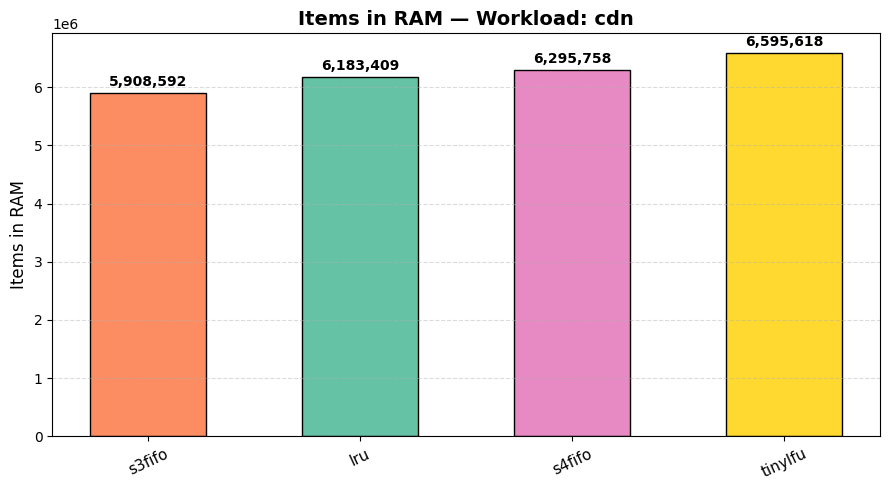

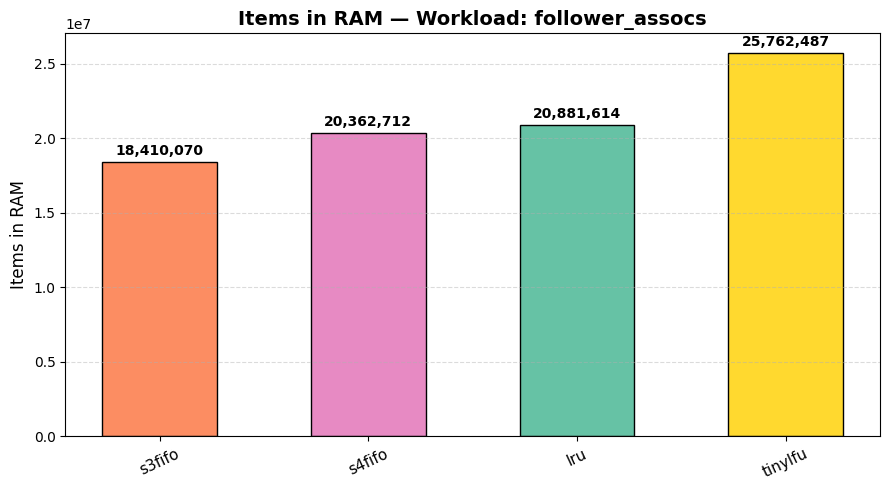

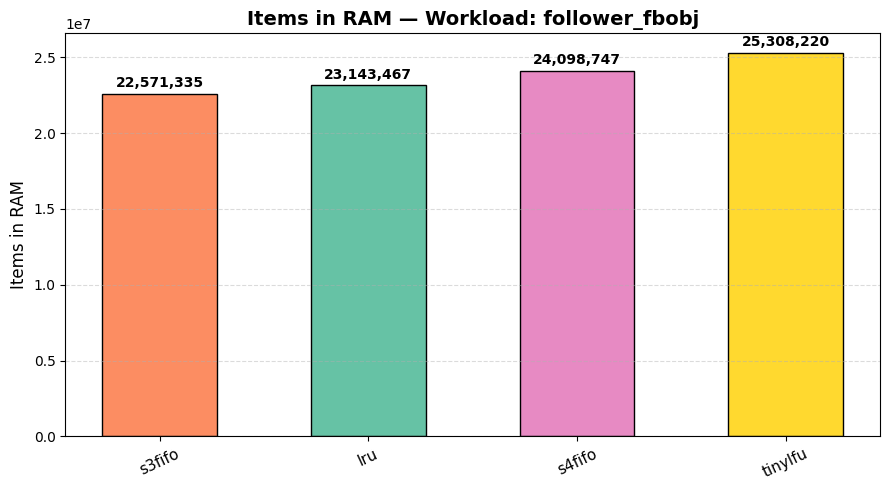

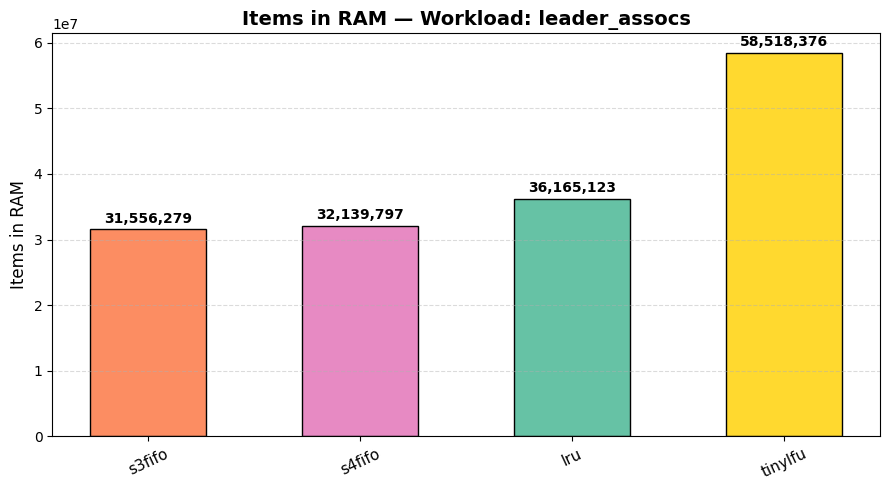

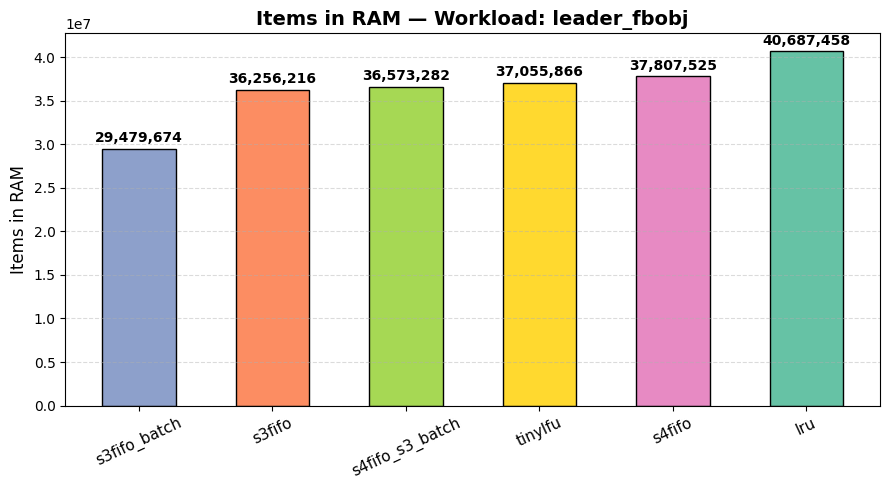

In [3]:
plot_metric_per_workload(
    df,
    metric="items_ram",
    title="Items in RAM",
    ylabel="Items in RAM",
    value_fmt="{:,.0f}",
)


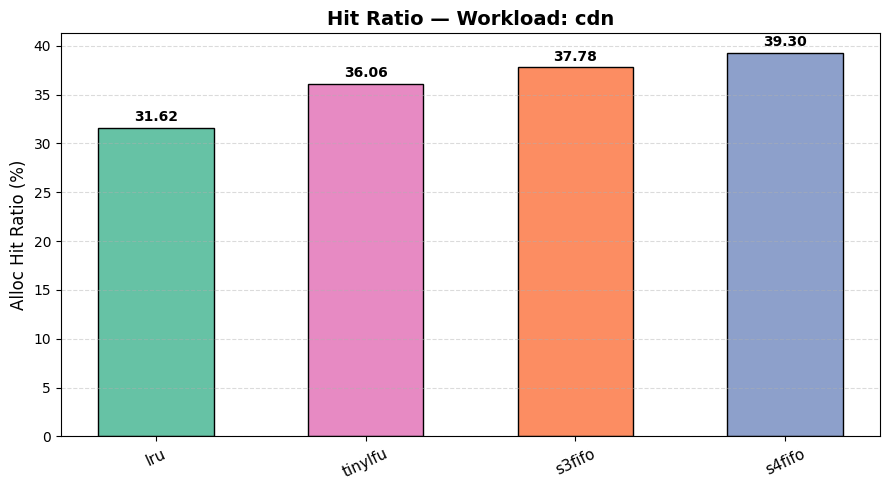

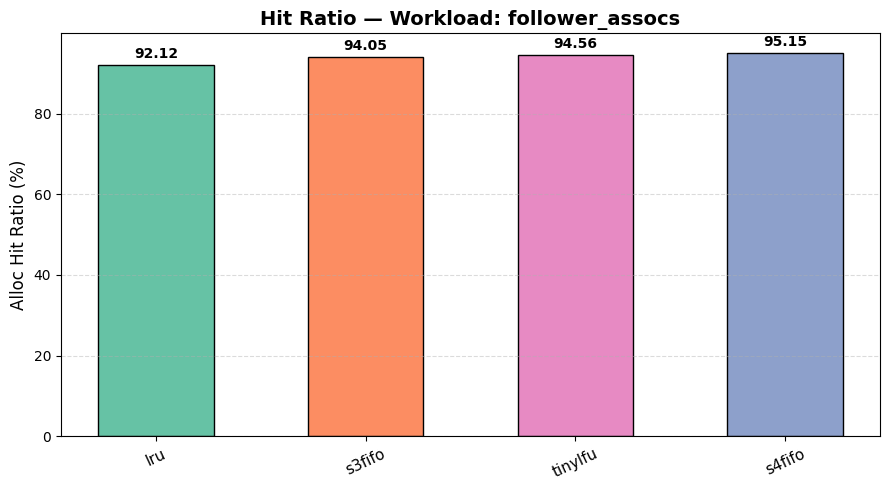

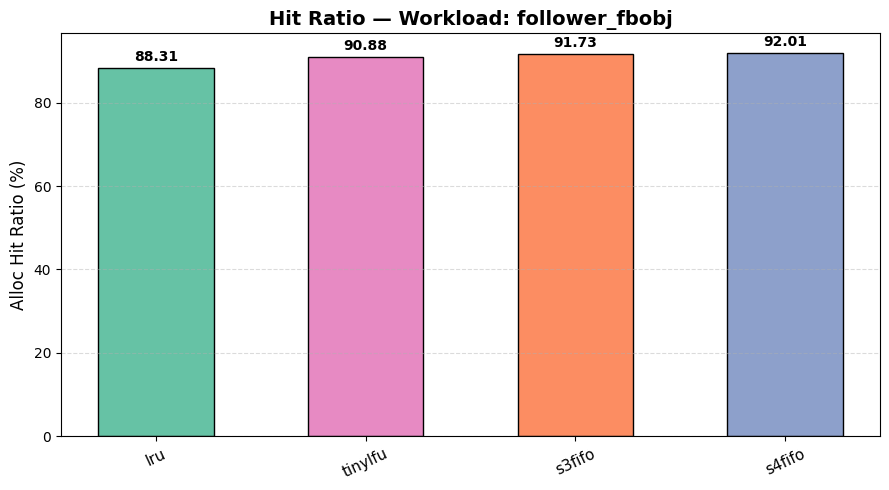

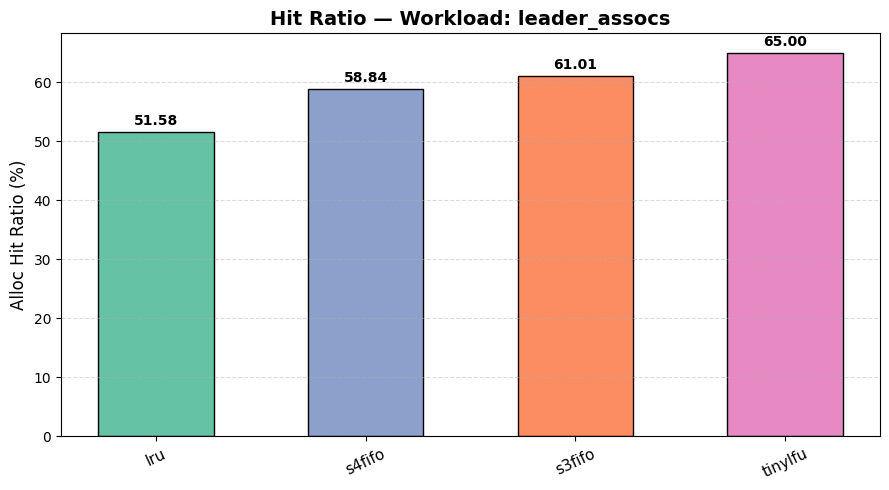

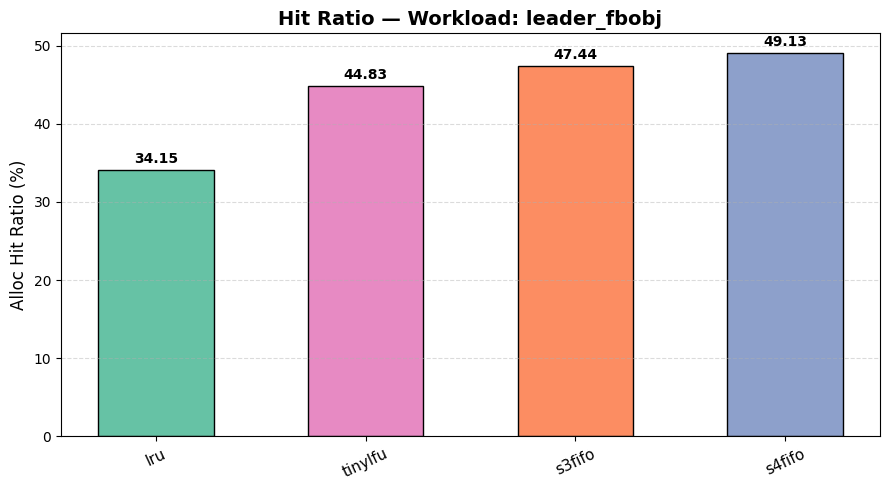

In [14]:
plot_metric_per_workload(
    df,
    metric="alloc_hit_ratio",
    title="Hit Ratio",
    ylabel="Alloc Hit Ratio (%)",
    value_fmt="{:.2f}",
)


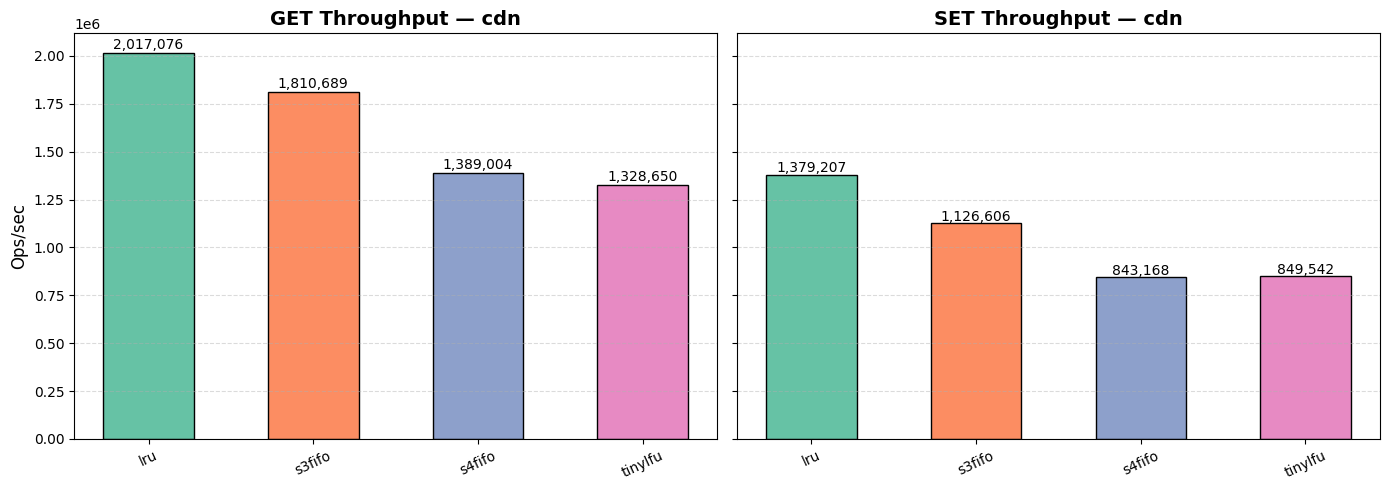

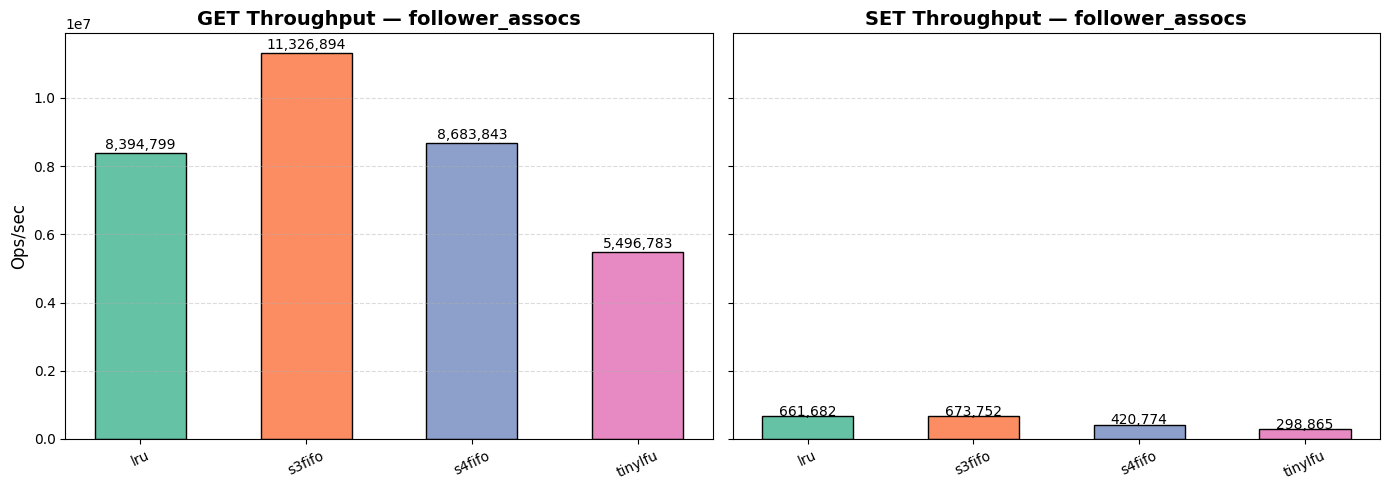

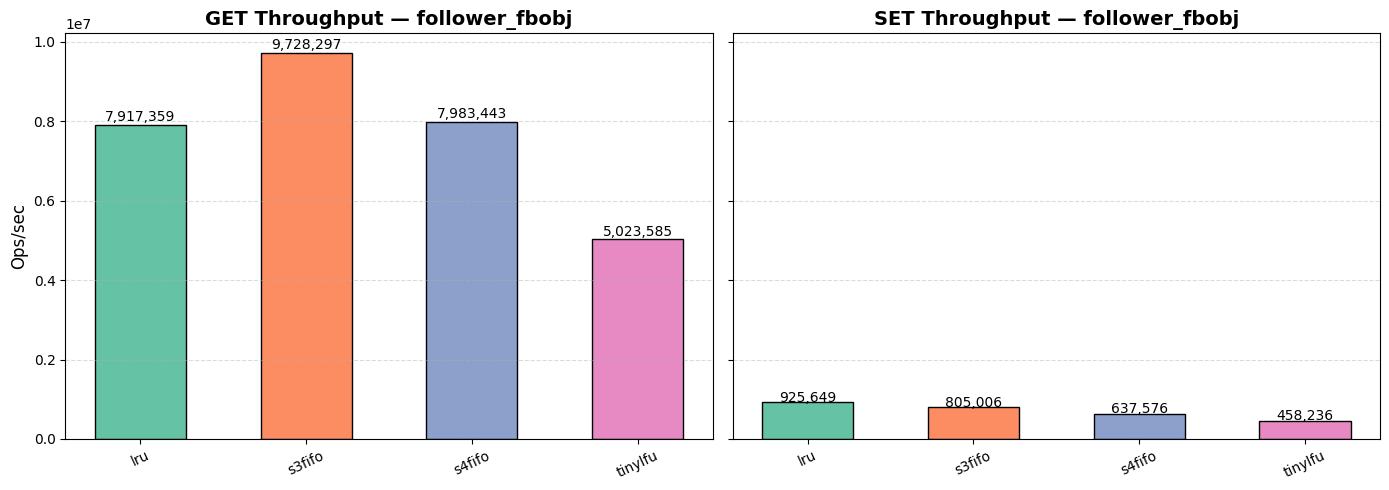

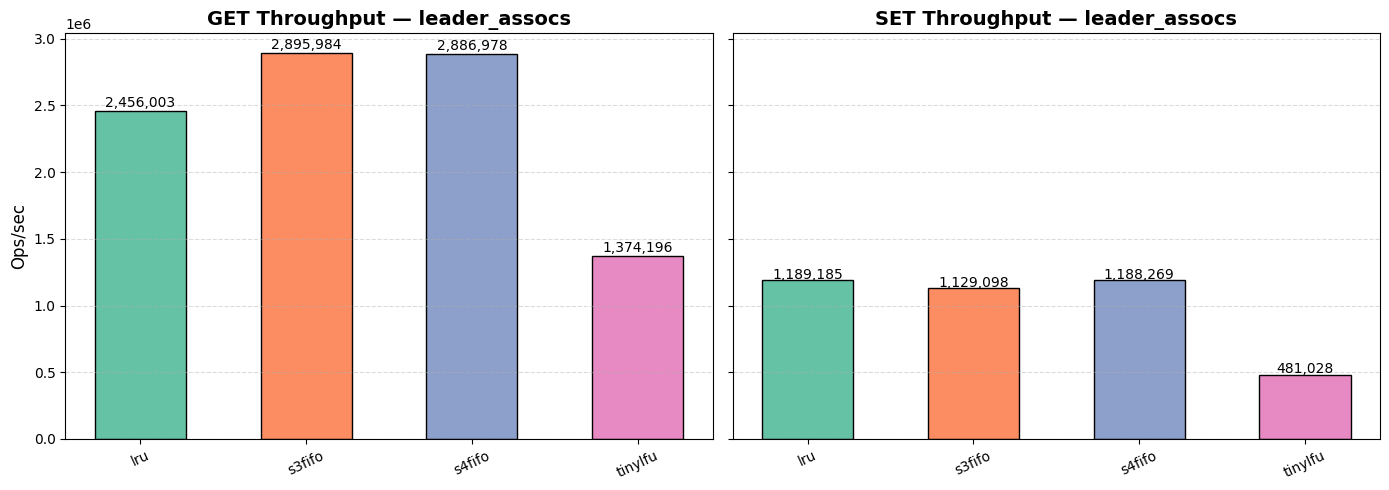

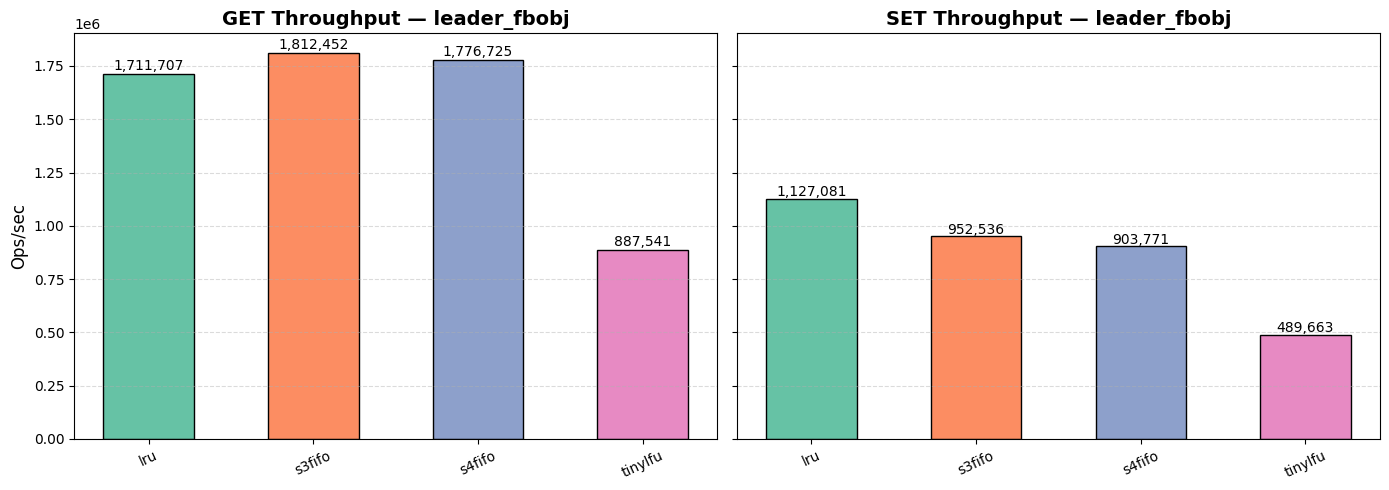

,algorithm,workload,get_tput,set_tput
0,lru,cdn,2017076.0,1379207.0
1,s3fifo,cdn,1810689.0,1126606.0
2,s4fifo,cdn,1389004.0,843168.0
3,tinylfu,cdn,1328650.0,849542.0
4,lru,follower_assocs,8394799.0,661682.0
5,s3fifo,follower_assocs,11326894.0,673752.0
6,s4fifo,follower_assocs,8683843.0,420774.0
7,tinylfu,follower_assocs,5496783.0,298865.0
8,lru,follower_fbobj,7917359.0,925649.0
9,s3fifo,follower_fbobj,9728297.0,805006.0


In [13]:
plot_throughput_per_workload_subplots(df)
df[["algorithm", "workload", "get_tput", "set_tput"]]


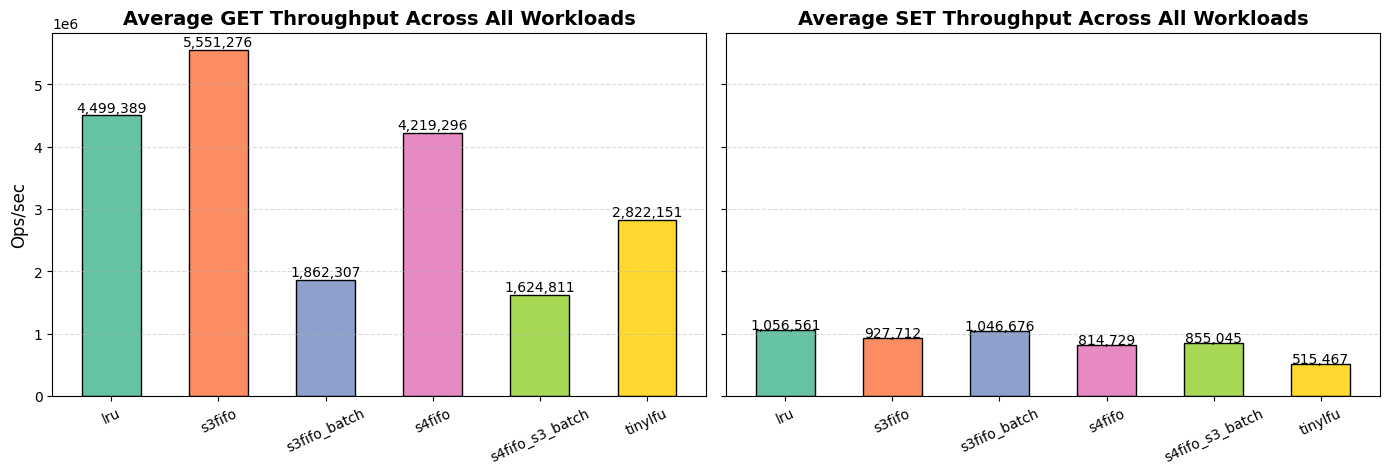

,algorithm,get_tput,set_tput
0,lru,4499388.8,1056560.8
1,s3fifo,5551276.4,927712.4
2,s3fifo_batch,1862307.0,1046676.0
3,s4fifo,4219295.6,814729.4
4,s4fifo_s3_batch,1624811.0,855045.0
5,tinylfu,2822151.0,515466.8


In [6]:
avg_df = plot_average_throughput(df)
avg_df
